# Standardized Level

In statistics, a **standardised level** (most commonly referred to as a **Standardized Score** or **Z-score**) is a way of transforming raw data so that it can be universally compared, regardless of its original units or scale.

Standardization takes any normal distribution of data—whether it is measuring human height in centimeters, salaries in dollars, or test scores in points—and forces it onto a single, universal mathematical playing field called the **Standard Normal Distribution**.

### The Standard Normal Distribution

When you standardize a dataset, you reshape it so that it always has two exact mathematical properties:

1. **The Mean ($\mu$) becomes exactly 0.**
2. **The Standard Deviation ($\sigma$) becomes exactly 1.**

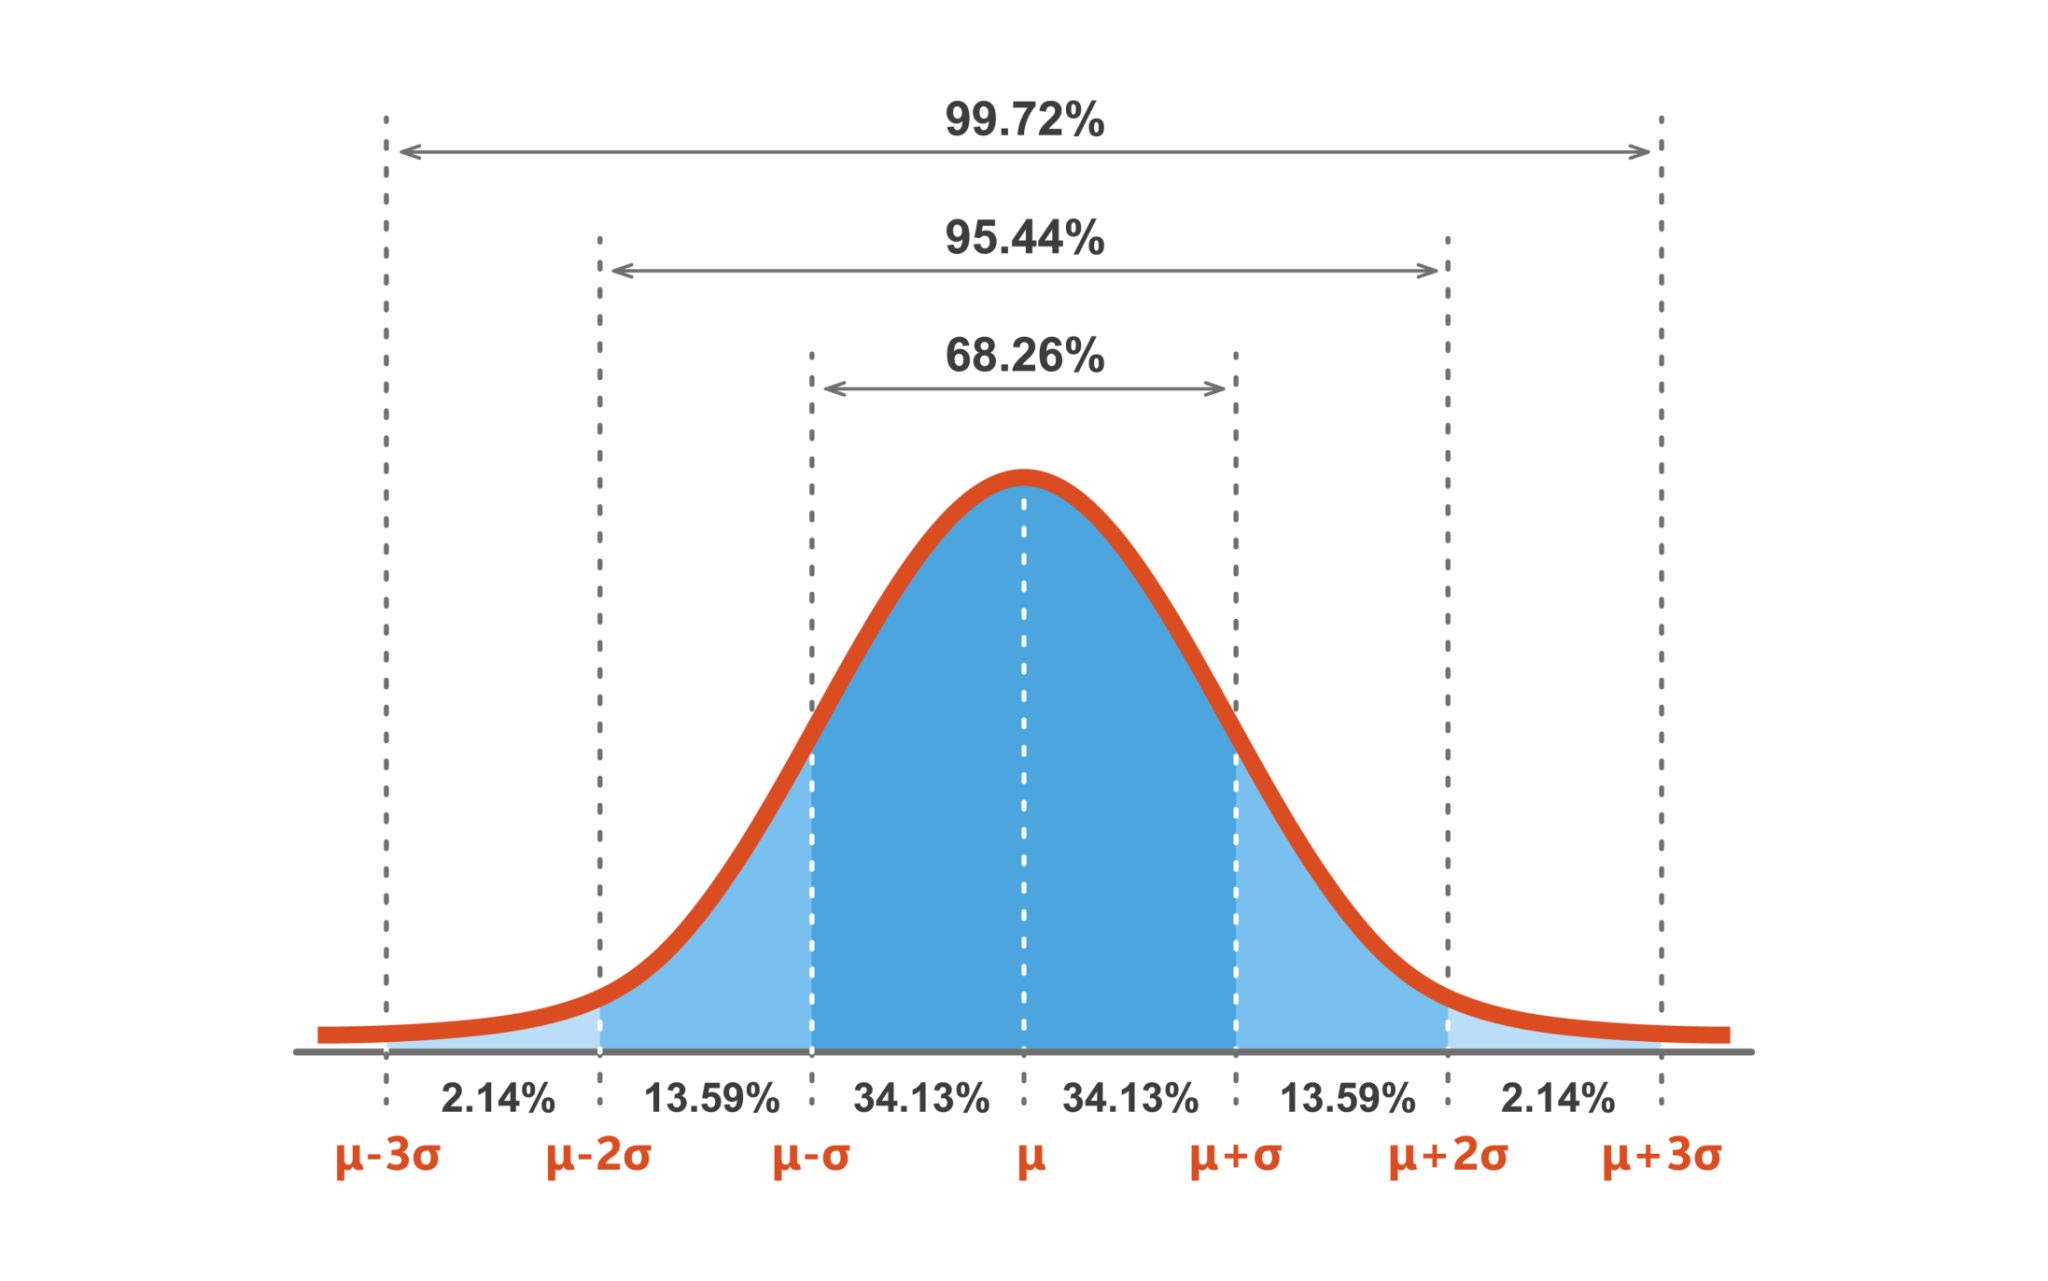

<center>The Standard Normal Distribution. Source: Elena Pimukova / Getty Images</center>

Once your data is on this curve, every single data point is converted into a **Z-score**. A Z-score simply tells you exactly how many standard deviations a specific data point is away from the mean.

* A Z-score of **0** means the data point is exactly average.
* A Z-score of **+1.5** means the data point is 1.5 standard deviations *above* the average.
* A Z-score of **-2.0** means the data point is 2 standard deviations *below* the average.

### The Z-Score Formula

To calculate the standardized level (Z-score) of any individual data point, you use this formula:

$$Z = \frac{x - \mu}{\sigma}$$

* **$Z$** = The standardized score (Z-score)
* **$x$** = The raw data point you want to standardize
* **$\mu$** = The mean of the dataset
* **$\sigma$** = The standard deviation of the dataset

*(Note: If you are working with a sample instead of a population, you substitute $\bar{x}$ for $\mu$ and $s$ for $\sigma$.)*

### Why Standardization is a Superpower: Apples to Oranges

The primary reason data scientists standardize data is to compare things that are fundamentally different.

**Example Scenario:**
Imagine you are a college admissions officer comparing two students who took different standardized tests:

* **Student A** scored a 1300 on the SAT. (SAT Mean = 1050, SD = 150)
* **Student B** scored a 28 on the ACT. (ACT Mean = 21, SD = 5)

You cannot compare 1300 to 28 directly. But you *can* standardize them by calculating their Z-scores:

* **Student A's Z-score:** $(1300 - 1050) / 150 = \mathbf{+1.67}$
* **Student B's Z-score:** $(28 - 21) / 5 = \mathbf{+1.40}$

By standardizing the levels, it instantly becomes clear: Student A actually performed better relative to their peers than Student B did, even though the tests use completely different scoring systems.

---

### Use in Machine Learning

Beyond basic comparisons, standardization is a mandatory preprocessing step for many machine learning algorithms (like K-Nearest Neighbors, Principal Component Analysis, or Neural Networks).

If a dataset includes a variable like "Age" (ranging from 18 to 80) and "Income" (ranging from $20,000 to $150,000), the algorithm might accidentally assume that "Income" is far more important just because the numbers are larger. Standardizing every variable forces them all onto the exact same scale, ensuring the algorithm treats them fairly based on their actual variance, not just their raw size.

Here is the complete Python code to build the interactive **Z-Score Transformation Engine** directly in a Google Colab notebook.

To make the sample data relatable, this engine defaults to the **college admissions scenario** we discussed earlier: comparing a raw SAT score to its standardized Z-score.

As you move the sliders, you will see exactly how shifting the mean, changing the spread (standard deviation), or moving the raw data point automatically translates onto the fixed, universal Standard Normal Distribution curve at the bottom.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import ipywidgets as widgets
from IPython.display import display

# ==========================================
# 1. Define the Visualization Engine
# ==========================================
def plot_standardization(raw_mean, raw_sd, raw_point):
    # Calculate the Z-score mathematically
    z_score = (raw_point - raw_mean) / raw_sd

    # Setup Figure with 2 vertically stacked subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

    # ----------------------------------------------------
    # TOP PLOT: The Raw Data Distribution (e.g., SAT Scores)
    # ----------------------------------------------------
    # The x-axis changes dynamically based on the raw mean and SD
    x_raw = np.linspace(raw_mean - 4*raw_sd, raw_mean + 4*raw_sd, 1000)
    y_raw = norm.pdf(x_raw, raw_mean, raw_sd)

    ax1.plot(x_raw, y_raw, color='forestgreen', linewidth=2)
    ax1.fill_between(x_raw, y_raw, color='forestgreen', alpha=0.1)

    # Highlight the specific raw data point
    ax1.axvline(raw_point, color='orange', linestyle='--', linewidth=2)
    ax1.scatter(raw_point, 0, color='red', s=150, zorder=5, edgecolors='black',
                label=f'Raw Data Point: {raw_point}')

    # Formatting Top Plot
    ax1.set_title(rf'Raw Data Distribution ($\mu={raw_mean}$, $\sigma={raw_sd}$)', fontsize=14, pad=10)
    ax1.set_xlabel('Raw Values (Original Units)', fontsize=12)
    ax1.set_ylabel('Probability Density', fontsize=12)
    ax1.set_xlim(raw_mean - 4*raw_sd, raw_mean + 4*raw_sd)
    ax1.grid(alpha=0.3)
    ax1.legend(loc='upper right')

    # ----------------------------------------------------
    # BOTTOM PLOT: The Standard Normal Distribution (Z-Scores)
    # ----------------------------------------------------
    # The x-axis is permanently fixed from -4 to 4
    x_z = np.linspace(-4, 4, 1000)
    y_z = norm.pdf(x_z, 0, 1)

    ax2.plot(x_z, y_z, color='royalblue', linewidth=2)
    ax2.fill_between(x_z, y_z, color='royalblue', alpha=0.1)

    # Highlight the transformed Z-score
    ax2.axvline(z_score, color='orange', linestyle='--', linewidth=2)
    ax2.scatter(z_score, 0, color='red', s=150, zorder=5, edgecolors='black',
                label=f'Calculated Z-Score: {z_score:.2f}')

    # Formatting Bottom Plot
    ax2.set_title(r'Standard Normal Distribution ($\mu=0$, $\sigma=1$)', fontsize=14, pad=10)
    ax2.set_xlabel('Z-Scores (Standard Deviations from Mean)', fontsize=12)
    ax2.set_ylabel('Probability Density', fontsize=12)
    ax2.set_xlim(-4, 4)
    ax2.grid(alpha=0.3)
    ax2.legend(loc='upper right')

    # Add a dynamic text box showing the exact formula transformation
    math_text = (
        f"Standardization Formula:\n"
        f"Z = (X - \u03BC) / \u03C3\n"
        f"Z = ({raw_point} - {raw_mean}) / {raw_sd}\n"
        f"Z = {z_score:.2f}"
    )
    props = dict(boxstyle='round,pad=0.8', facecolor='white', alpha=0.9, edgecolor='gray')
    ax2.text(0.02, 0.95, math_text, transform=ax2.transAxes, fontsize=12,
             verticalalignment='top', bbox=props)

    plt.tight_layout(pad=3.0)
    plt.show()

# ==========================================
# 2. Create Interactive Controls
# ==========================================
# Sliders are initialized with a standard SAT score scenario
mean_slider = widgets.IntSlider(
    value=1050, min=500, max=1500, step=10,
    description='Raw Mean (\u03BC):', continuous_update=False,
    style={'description_width': 'initial'}, layout=widgets.Layout(width='500px')
)

sd_slider = widgets.IntSlider(
    value=150, min=10, max=500, step=10,
    description='Raw SD (\u03C3):', continuous_update=False,
    style={'description_width': 'initial'}, layout=widgets.Layout(width='500px')
)

point_slider = widgets.IntSlider(
    value=1300, min=400, max=1600, step=10,
    description='Raw Data Point (X):', continuous_update=True,
    style={'description_width': 'initial'}, layout=widgets.Layout(width='500px')
)

# Link the sliders to the visualization function
interactive_plot = widgets.interactive(
    plot_standardization,
    raw_mean=mean_slider,
    raw_sd=sd_slider,
    raw_point=point_slider
)

# Display the interactive UI
display(interactive_plot)

interactive(children=(IntSlider(value=1050, continuous_update=False, description='Raw Mean (μ):', layout=Layou…

### What to look for when you run it:

* **Drag the `Raw Data Point` slider:** Watch how the red dot on the top graph moves across the raw values, while the red dot on the bottom graph perfectly mirrors its movement, mapping the raw score to its exact standard deviation distance from the center.
* **Increase the `Raw SD`:** You'll notice the top graph's x-axis numbers change to accommodate the wider spread. Even if you leave the Raw Data Point at 1300, increasing the standard deviation makes that score less "special," which is mathematically reflected by the Z-score dropping closer to 0 on the bottom graph.